# MB42 Dice Evaluation

This notebook reads the class-wise Dice scores written by `run_evaluation_mb42.py` and creates the boxplot visualization.

In [20]:
%pip install -q pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import seaborn as sns

sns.set_theme(style="ticks", context="paper")

In [22]:
score_candidates = [
    Path("outputs/mb59_to_mb42_mindboggle101_gif/score.csv"),
    Path("../outputs/mb59_to_mb42_mindboggle101_gif/score.csv"),
]
score_csv = next((path for path in score_candidates if path.is_file()), None)
if score_csv is None:
    raise FileNotFoundError("Run run_evaluation_mb42.py first to create score.csv")

LABEL_NAMES = {
    2: "Left-Cerebral-White-Matter",
    4: "Left-Lateral-Ventricle",
    5: "Left-Inf-Lat-Vent",
    7: "Left-Cerebellum-White-Matter",
    8: "Left-Cerebellum-Cortex",
    10: "Left-Thalamus-Proper",
    11: "Left-Caudate",
    12: "Left-Putamen",
    13: "Left-Pallidum",
    14: "3rd-Ventricle",
    15: "4th-Ventricle",
    16: "Brain-Stem",
    17: "Left-Hippocampus",
    18: "Left-Amygdala",
    24: "CSF",
    26: "Left-Accumbens-area",
    28: "Left-VentralDC",
    30: "Left-vessel",
    31: "Left-choroid-plexus",
    41: "Right-Cerebral-White-Matter",
    43: "Right-Lateral-Ventricle",
    44: "Right-Inf-Lat-Vent",
    46: "Right-Cerebellum-White-Matter",
    47: "Right-Cerebellum-Cortex",
    49: "Right-Thalamus-Proper",
    50: "Right-Caudate",
    51: "Right-Putamen",
    52: "Right-Pallidum",
    53: "Right-Hippocampus",
    54: "Right-Amygdala",
    58: "Right-Accumbens-area",
    60: "Right-VentralDC",
    62: "Right-vessel",
    63: "Right-choroid-plexus",
    72: "5th-Ventricle",
    77: "WM-hypointensities",
    80: "non-WM-hypointensities",
    85: "Optic-Chiasm",
    251: "CC_Posterior",
    252: "CC_Mid_Posterior",
    253: "CC_Central",
    254: "CC_Mid_Anterior",
    255: "CC_Anterior",
    1000: "ctx-lh-unknown",
    1002: "ctx-lh-caudalanteriorcingulate",
    1003: "ctx-lh-caudalmiddlefrontal",
    1005: "ctx-lh-cuneus",
    1006: "ctx-lh-entorhinal",
    1007: "ctx-lh-fusiform",
    1008: "ctx-lh-inferiorparietal",
    1009: "ctx-lh-inferiortemporal",
    1010: "ctx-lh-isthmuscingulate",
    1011: "ctx-lh-lateraloccipital",
    1012: "ctx-lh-lateralorbitofrontal",
    1013: "ctx-lh-lingual",
    1014: "ctx-lh-medialorbitofrontal",
    1015: "ctx-lh-middletemporal",
    1016: "ctx-lh-parahippocampal",
    1017: "ctx-lh-paracentral",
    1018: "ctx-lh-parsopercularis",
    1019: "ctx-lh-parsorbitalis",
    1020: "ctx-lh-parstriangularis",
    1021: "ctx-lh-pericalcarine",
    1022: "ctx-lh-postcentral",
    1023: "ctx-lh-posteriorcingulate",
    1024: "ctx-lh-precentral",
    1025: "ctx-lh-precuneus",
    1026: "ctx-lh-rostralanteriorcingulate",
    1027: "ctx-lh-rostralmiddlefrontal",
    1028: "ctx-lh-superiorfrontal",
    1029: "ctx-lh-superiorparietal",
    1030: "ctx-lh-superiortemporal",
    1031: "ctx-lh-supramarginal",
    1034: "ctx-lh-transversetemporal",
    1035: "ctx-lh-insula",
    2000: "ctx-rh-unknown",
    2002: "ctx-rh-caudalanteriorcingulate",
    2003: "ctx-rh-caudalmiddlefrontal",
    2005: "ctx-rh-cuneus",
    2006: "ctx-rh-entorhinal",
    2007: "ctx-rh-fusiform",
    2008: "ctx-rh-inferiorparietal",
    2009: "ctx-rh-inferiortemporal",
    2010: "ctx-rh-isthmuscingulate",
    2011: "ctx-rh-lateraloccipital",
    2012: "ctx-rh-lateralorbitofrontal",
    2013: "ctx-rh-lingual",
    2014: "ctx-rh-medialorbitofrontal",
    2015: "ctx-rh-middletemporal",
    2016: "ctx-rh-parahippocampal",
    2017: "ctx-rh-paracentral",
    2018: "ctx-rh-parsopercularis",
    2019: "ctx-rh-parsorbitalis",
    2020: "ctx-rh-parstriangularis",
    2021: "ctx-rh-pericalcarine",
    2022: "ctx-rh-postcentral",
    2023: "ctx-rh-posteriorcingulate",
    2024: "ctx-rh-precentral",
    2025: "ctx-rh-precuneus",
    2026: "ctx-rh-rostralanteriorcingulate",
    2027: "ctx-rh-rostralmiddlefrontal",
    2028: "ctx-rh-superiorfrontal",
    2029: "ctx-rh-superiorparietal",
    2030: "ctx-rh-superiortemporal",
    2031: "ctx-rh-supramarginal",
    2034: "ctx-rh-transversetemporal",
    2035: "ctx-rh-insula",
}

output_dir = score_csv.parent
boxplot_pdf = output_dir / "mb42_dice_boxplot.pdf"
scores = pd.read_csv(score_csv)
scores["label_id"] = scores["label"].astype(int)
scores["class_name"] = scores["label_id"].map(LABEL_NAMES).fillna("label-" + scores["label_id"].astype(str))
scores["label"] = scores["label_id"].astype(str)
scores["target_structure"] = scores["label"] + ": " + scores["class_name"]
scores.head()


,subject,label,dice,label_id,class_name,target_structure
0,NKI-RS-22-1,2,0.949633,2,Left-Cerebral-White-Matter,2: Left-Cerebral-White-Matter
1,NKI-RS-22-1,4,0.944822,4,Left-Lateral-Ventricle,4: Left-Lateral-Ventricle
2,NKI-RS-22-1,5,0.660900,5,Left-Inf-Lat-Vent,5: Left-Inf-Lat-Vent
3,NKI-RS-22-1,7,0.862084,7,Left-Cerebellum-White-Matter,7: Left-Cerebellum-White-Matter
4,NKI-RS-22-1,8,0.953172,8,Left-Cerebellum-Cortex,8: Left-Cerebellum-Cortex


In [23]:
pd.DataFrame([
    {
        "subjects": scores["subject"].nunique(),
        "labels": scores["label"].nunique(),
        "rows": len(scores),
        "mean_dice": scores["dice"].mean(),
        "std_dice": scores["dice"].std(),
    }
])

,subjects,labels,rows,mean_dice,std_dice
0,42,107,4488,0.783925,0.153303


PosixPath('../outputs/mb59_to_mb42_mindboggle101_gif/mb42_dice_boxplot.pdf')

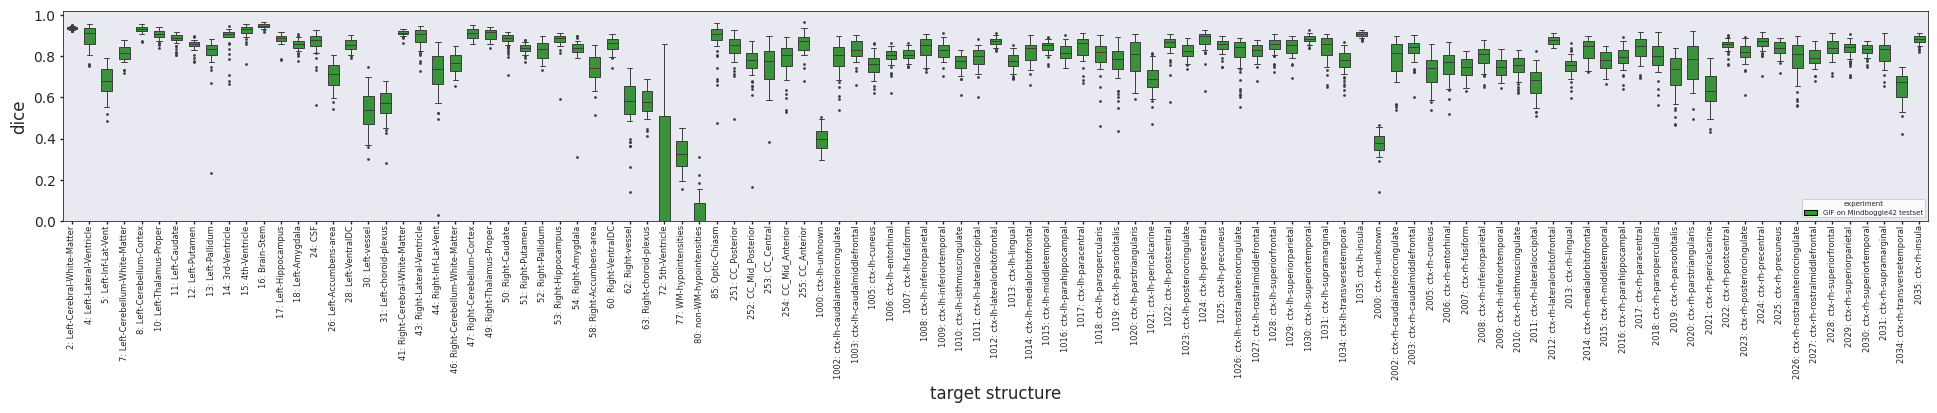

In [24]:
label_ids = sorted(scores["label_id"].unique())
label_order = [f"{label}: {LABEL_NAMES.get(label, f'label-{label}')}" for label in label_ids]
plot_scores = scores.copy()
plot_scores["experiment"] = "GIF on Mindboggle42 testset"

fig_width = max(14, min(24, 0.18 * len(label_order)))
fig, ax = plt.subplots(figsize=(fig_width, 4.0))
ax.set_facecolor("#e9e9f2")

sns.boxplot(
    data=plot_scores,
    x="target_structure",
    y="dice",
    hue="experiment",
    order=label_order,
    palette={"GIF on Mindboggle42 testset": "#2ca02c"},
    showfliers=True,
    fliersize=1.0,
    linewidth=0.7,
    width=0.62,
    whis=0.8,
    ax=ax,
)

ax.set_xlabel("target structure", fontsize=12)
ax.set_ylabel("dice", fontsize=12)
ax.set_ylim(0, 1.02)
ax.tick_params(axis="x", rotation=90, labelsize=6, length=2, pad=1)
ax.tick_params(axis="y", labelsize=10, length=2)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.6)

legend_handles = [Patch(facecolor="#2ca02c", edgecolor="black", label="GIF on Mindboggle42 testset")]
ax.legend(
    handles=legend_handles,
    title="experiment",
    loc="lower right",
    fontsize=5,
    title_fontsize=5,
    frameon=True,
    framealpha=0.85,
    borderpad=0.2,
)

fig.tight_layout(pad=0.3)
fig.savefig(boxplot_pdf, bbox_inches="tight")
boxplot_pdf
